<a href="https://colab.research.google.com/github/Flspo/Inform-tica/blob/main/Aula_de_inform%C3%A1tica_dia_14_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'temperature-and-ice-cream-sales' dataset.
Path to dataset files: /kaggle/input/temperature-and-ice-cream-sales


In [6]:
import pandas as pd

In [10]:
import os

# Get the list of files in the downloaded path
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

# Construct full path and read the CSV
full_path = os.path.join(path, csv_file)
df = pd.read_csv(full_path)

# Display the first few rows to confirm
df.head()

,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02


In [11]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare the data
X = df['Temperature'].values.reshape(-1, 1) # Independent variable (features)
y = df['Ice Cream Profits'].values         # Dependent variable (target)

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print the coefficients
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


Coefficient: 1.19
Intercept: -33.70


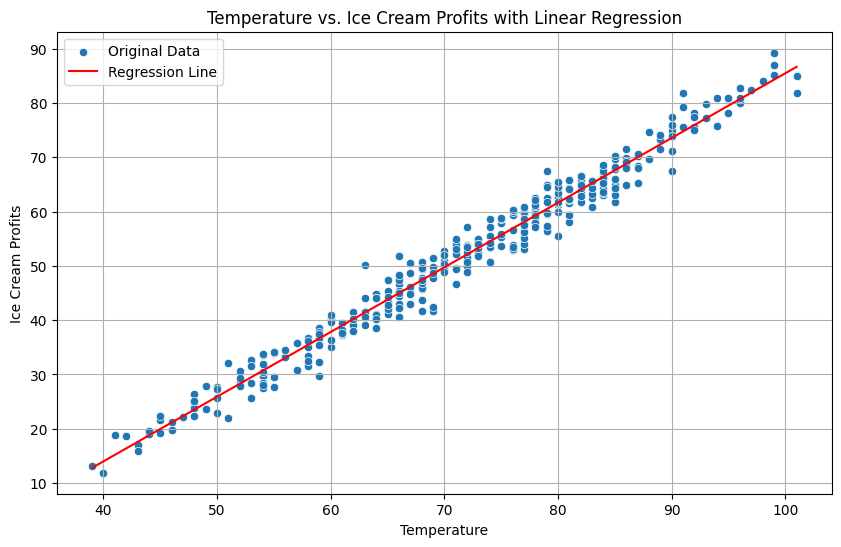

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Ice Cream Profits', data=df, label='Original Data')

# Plot the regression line
plt.plot(X, model.predict(X), color='red', label='Regression Line')

plt.title('Temperature vs. Ice Cream Profits with Linear Regression')
plt.xlabel('Temperature')
plt.ylabel('Ice Cream Profits')
plt.grid(True)
plt.legend()
plt.show()